<a href="https://colab.research.google.com/github/giu-mzx/Checkpoint_01_SERS/blob/main/Desafio_Final_Energia_ONS_API_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

In [5]:
type(registros)

list

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [7]:
dados.shape

(336, 11)

In [8]:
dados = pd.DataFrame(registros)
linhas, colunas = dados.shape
atributos = dados.columns

print("Quantidade de linhas:", linhas)
print("Quantidade de colunas:", colunas)
print("\nNomes dos atributos:")
print(list(atributos))

print("\nInfo():")
dados.info()

print("\nDescribe():")
print(dados.describe())

Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   v

Identificação dos atributos necessários

dat_referencia: data de referência da medição.

din_referenciautc: data e hora da medição em UTC.

din_atualizacao: data e hora em que o registro foi atualizado na API.

cod_areacarga: código da área de carga.

val_cargaglobal: valor da carga global.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [9]:
dados = dados.rename(columns={
    'cod_areacarga':'AreaCarga',
    'din_atualizacao':'Atualizacao',
    'dat_referencia':'DataReferencia',
    'din_referenciautc':'DataUtc',
    'val_cargaglobal':'CargaGlobal',
    'val_cargaglobalcons':'CargaGlobalCons',
    'val_cargaglobalsmmgd':'CargaGlobalMmgd',
    'val_cargasupervisionada':'CargaSupervisionada',
    'val_carganaosupervisionada':'CargaNaoSupervisionada',
    'val_cargammgd':'CargaMmgd',
    'val_consistencia':'Consistencia'
})

AtriImp = ['AreaCarga','Atualizacao','DataReferencia','DataUtc','CargaGlobal','CargaGlobalCons']
dados_org = dados[AtriImp].copy()

print("Valores ausentes por atributo:")
print(dados_org.isnull().sum())

dados_org['CargaGlobal'] = pd.to_numeric(dados_org['CargaGlobal'], errors='coerce')

print("\nValores ausentes em CargaGlobal após conversão:")
print(dados_org['CargaGlobal'].isnull().sum())


print("\nTipos de dados:")
print(dados_org.dtypes)

Valores ausentes por atributo:
AreaCarga          0
Atualizacao        0
DataReferencia     0
DataUtc            0
CargaGlobal        0
CargaGlobalCons    0
dtype: int64

Valores ausentes em CargaGlobal após conversão:
0

Tipos de dados:
AreaCarga           object
Atualizacao         object
DataReferencia      object
DataUtc             object
CargaGlobal        float64
CargaGlobalCons    float64
dtype: object


## Decisões de Tratamento:

Atributos renomeados para nomes mais simples.

Novo DataFrame criado, mantendo apenas os atributos necessários: AreaCarga, DataReferencia, DataUtc, CargaGlobal, CargaGlobalCons.

Verificação de valores ausentes nas variáveis permanecentes nenhum valor ausente encontrado.

Verificação do tipo da variável CargaGlobal: convertida para numérica (float).

Verificação das variáveis de data e hora: estavam em formato de texto e foram convertidas para data/hora, para permitir gráficos e ordenação ao longo do tempo.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [10]:
carga_min = dados_org['CargaGlobal'].min()
carga_max = dados_org['CargaGlobal'].max()
carga_media = dados_org['CargaGlobal'].mean()
med = dados_org['CargaGlobal'].median()
amp = carga_max - carga_min
qnt_med = dados_org['CargaGlobal'].count()
print(f"Carga mínima: {carga_min:.2f}")
print(f"Carga máxima: {carga_max:.2f}")
print(f"Carga média: {carga_media:.2f}")
print(f"Mediana: {med:.2f}")
print(f"Amplitude: {amp:.2f}")
print(f"Quantidade total de medições: {qnt_med}")

Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Quantidade total de medições: 336


# Comparação do valor máximo

O valor máximo foi de 23.185,31 MW, ficando cerca de 30% acima da média e 27% acima da mediana. Isso mostra que esse valor representa um pico de demanda e está bem acima dos valores mais comuns do conjunto de dados.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [11]:
dados_org["DataUtc"] = pd.to_datetime(dados_org["DataUtc"])
dados_org["CargaGlobal"] = pd.to_numeric(dados_org["CargaGlobal"])

carga_maxima = dados_org["CargaGlobal"].max()
limiar = carga_maxima * 0.9
print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Limiar (90%): {limiar:.2f}")

alta_demanda = dados_org[dados_org["CargaGlobal"] > limiar]

qtd_alta_demanda = len(alta_demanda)
total_registros = len(dados_org)
print(f"Registros em alta demanda: {qtd_alta_demanda}")
print(f"Total de registros: {total_registros}")

percentual = (qtd_alta_demanda / total_registros) * 100
print(f"Percentual do total: {percentual:.2f}%")

pico_valor = alta_demanda["CargaGlobal"].max()
print(f"Valor de pico: {pico_valor:.2f}")

linha_pico = dados_org.loc[dados_org["CargaGlobal"].idxmax()]
print(f"Data/hora do pico (UTC): {linha_pico['DataUtc']}")

Carga máxima: 23185.31
Limiar (90%): 20866.78
Registros em alta demanda: 50
Total de registros: 336
Percentual do total: 14.88%
Valor de pico: 23185.31
Data/hora do pico (UTC): 2025-08-01 22:00:00+00:00


**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

Representam uma parcela relativamente pequena. Apenas 50 dos 336 registros (14,88%) ultrapassaram o limiar de alta demanda (20.866,78 MW). O pico ocorreu em 01/08/2025 às 22:00 UTC (19:00 em Brasília). Isso confirma que a alta demanda se concentra em uma janela curta do dia, e não se estende por longos períodos.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

##**1 - Critério Escolhido**


**Critério escolhido**: carga acima da média. Foram selecionados os registros cuja carga global é superior à carga média de todo o período analisado.

## **2 - O novo DataFrame**

In [12]:
media_carga = dados_org["CargaGlobal"].mean()

df_acima_media = dados_org[dados_org["CargaGlobal"] > media_carga].copy()

In [13]:
df_acima_media.head()

,AreaCarga,Atualizacao,DataReferencia,DataUtc,CargaGlobal,CargaGlobalCons
15,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023
16,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395
17,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176
18,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504
19,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822


## **3 - A quantidade de registros**


In [14]:
quantidade_acima_media = len(df_acima_media)

print("Quantidade de registros acima da média:", quantidade_acima_media)

Quantidade de registros acima da média: 184


## **4 - O percentual**

In [15]:
percentual_acima_media = (quantidade_acima_media / len(dados_org)) * 100

print(f"Percentual acima da média: {percentual_acima_media:.2f}%")

Percentual acima da média: 54.76%


## **5 - A comparação com o conjunto de alta demanda.**

O critério de carga acima da média apresentou 184 registros (54,76%), enquanto o critério de alta demanda apresentou 50 registros (14,88%). Dessa forma, o critério de carga acima da média identificou uma quantidade maior de registros, pois é menos restritivo que o critério de alta demanda, que considera apenas valores superiores a 90% da carga máxima.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

## **1 - Gráfico da carga ao longo do tempo**

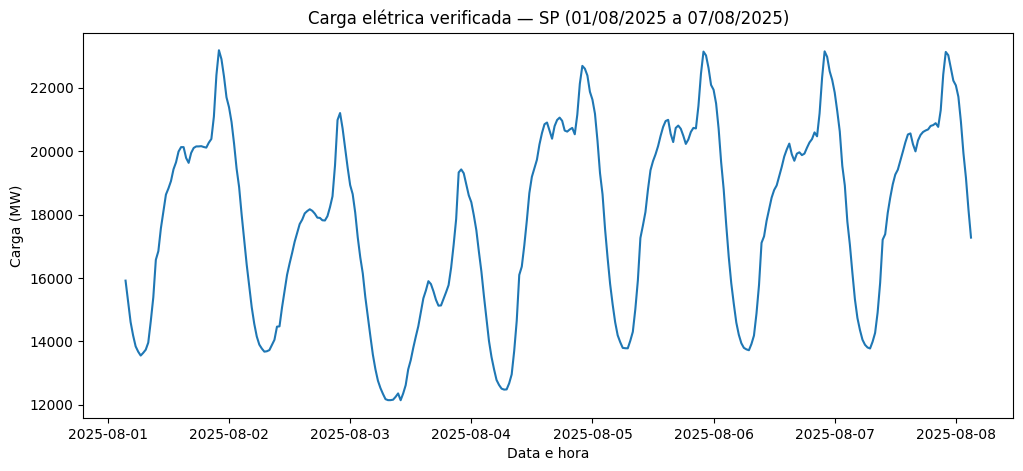

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(dados_org["DataUtc"], dados_org["CargaGlobal"])
plt.title("Carga elétrica verificada — SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data e hora")
plt.ylabel("Carga (MW)")
plt.show()

A carga apresenta um padrão de ciclos diários, com picos em horários específicos do dia, que se repete ao longo dos sete dias analisados.

## **2 - Gráfico escolhido pela equipe: comparação entre os critérios**

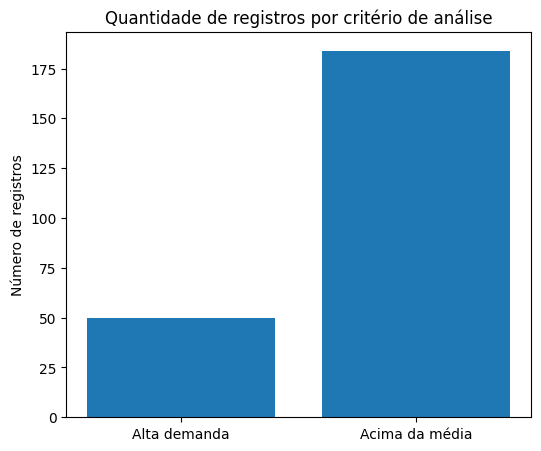

In [17]:
categorias = ["Alta demanda", "Acima da média"]
quantidades = [len(alta_demanda), len(df_acima_media)]

plt.figure(figsize=(6, 5))
plt.bar(categorias, quantidades)
plt.title("Quantidade de registros por critério de análise")
plt.ylabel("Número de registros")
plt.show()

O critério "acima da média" apresenta mais registros do que o critério de "alta demanda", pois é um limite menos restritivo.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [18]:
resumo_resultados = f'''
Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {qnt_med}
Carga mínima: {carga_min:.2f}
Carga máxima: {carga_max:.2f}
Carga média: {carga_media:.2f}
Mediana: {med:.2f}
Limiar de alta demanda: {limiar:.2f}
Registros de alta demanda: {qtd_alta_demanda} ({percentual:.2f}%)
Momento do pico: {linha_pico["DataUtc"]}
Segundo critério (carga acima da média): {quantidade_acima_media} registros ({percentual_acima_media:.2f}%)
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Limiar de alta demanda: 20866.78
Registros de alta demanda: 50 (14.88%)
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (carga acima da média): 184 registros (54.76%)



# Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [19]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 28.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [20]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [21]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [22]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA – REGIÃO SP**

**Data de emissão:** 08/08/2025  
**Responsável:** Analista de Dados do Setor Elétrico  

---

### 1. Caracterização do Conjunto Analisado
O presente relatório avalia o comportamento da carga elétrica na região de São Paulo (SP) durante o período de 01/08/2025 a 07/08/2025. O conjunto de dados é composto por um total de **336 registros** temporais.

---

### 2. Principais Indicadores
Os dados estatísticos descritivos do período apresentam os seguintes valores:

* **Carga Mínima:** 12.139,25
* **Carga Máxima (Pico):** 23.185,31
* **Carga Média:** 17.870,83
* **Mediana:** 18.199,13

*Observação dos dados:* A mediana (18.199,13) apresenta valor superior à carga média (17.870,83), indicando uma distribuição de dados com leve assimetria à esquerda, influenciada pelos valores mais baixos registrados no período.

---

### 3. Análise dos Períodos de Alta Demanda
A alta demanda foi delimitada pelo limiar de **20.866,78**.

* **Regi

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

**1. Os indicadores foram utilizados corretamente?**

Os principais indicadores foram utilizados corretamente. Os valores de carga mínima, máxima, média, mediana, amplitude, quantidade de registros, limiar de alta demanda e percentuais apresentados no relatório correspondem aos cálculos realizados no notebook.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**

Sim. Algumas afirmações da resposta original foram além do que os dados permitem afirmar. O relatório utilizou expressões como “14,88% do período operou” e “54,76% do período manteve-se acima”. Como a análise foi realizada sobre registros, o correto é afirmar que 50 dos 336 registros (14,88%) ultrapassaram o limiar de alta demanda e que 184 dos 336 registros (54,76%) ficaram acima da média.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**

Sim. A resposta original utilizou expressões como “maior parte do tempo”, “fração menor do tempo” e “episódios de alta demanda foram concentrados e pontuais”. Essas interpretações não são necessárias e não podem ser determinadas diretamente apenas pela contagem dos registros. Além disso, embora o relatório tenha apresentado possíveis causas como hipóteses, elas não eram necessárias para a análise e poderiam gerar interpretações que não são sustentadas pelos dados.

**4. Que alterações a equipe realizou no texto?**

A equipe revisou o relatório para:

substituir referências a "tempo" por "registros analisados";
apresentar os percentuais como proporções dos 336 registros;
remover a afirmação de que a alta demanda ocorreu de forma "concentrada e pontual";
remover a interpretação de que a diferença entre mediana e média indicaria "concentração" na metade superior dos dados, por não ser uma conclusão estatística sustentada apenas por essa comparação;
evitar interpretações que não fossem necessárias para responder aos resultados;
manter apenas informações que podem ser confirmadas pelos cálculos realizados;
deixar claro que as causas das variações de carga não podem ser determinadas pelos dados disponíveis.

# **RELATÓRIO**

**1. Caracterização do Conjunto Analisado**

O conjunto de dados analisado apresenta medições da carga elétrica da região de São Paulo (SP), no período de 01/08/2025 a 07/08/2025. Foram analisados 336 registros.

**2. Principais Indicadores**

Os principais indicadores calculados foram:

Carga mínima: 12.139,25 MW
Carga máxima: 23.185,31 MW
Carga média: 17.870,83 MW
Mediana: 18.199,13 MW
Amplitude: 11.046,06 MW

A carga máxima de 23.185,31 MW foi superior à média e à mediana. A média e a mediana apresentaram valores próximos, com diferença de 328,30 MW entre elas.

**3. Análise dos Períodos de Alta Demanda**

Para identificar os registros de alta demanda, foi utilizado o critério de carga superior a 90% da carga máxima.

O limiar calculado foi de 20.866,78 MW. Foram identificados 50 registros acima desse valor, correspondendo a 14,88% dos 336 registros analisados.

O maior valor de carga registrado foi de 23.185,31 MW, ocorrido em 01/08/2025 às 22:00:00 UTC.

Os dados permitem identificar os registros que ultrapassaram o limiar e o momento do pico, mas não permitem determinar as causas das variações observadas.

**4. Comparação com o Segundo Critério**

Como segundo critério, foram selecionados os registros com carga estritamente acima da média, ou seja, superiores a 17.870,83 MW.

Esse critério resultou em 184 registros, correspondendo a 54,76% dos 336 registros analisados.

Comparando os dois critérios, o critério de carga acima da média apresentou 134 registros a mais que o critério de alta demanda, além de uma diferença de 39,88 pontos percentuais.

O critério de alta demanda é mais restritivo, pois considera somente valores superiores a 90% da carga máxima, enquanto o segundo critério considera todos os valores acima da média.

**5. Conclusão**

A análise dos 336 registros de carga elétrica da região de São Paulo, no período de 01/08/2025 a 07/08/2025, apresentou valores entre 12.139,25 MW e 23.185,31 MW.

O critério de alta demanda identificou 50 registros (14,88%), enquanto o critério de carga acima da média identificou 184 registros (54,76%).

Os resultados mostram que o critério de alta demanda é mais restritivo e seleciona uma quantidade menor de registros. As causas das variações de carga e do pico identificado não podem ser determinadas apenas com os dados utilizados nesta análise.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**